# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Lau Zheng Yuan Gavin
* Student ID: 2501290G
* Class: PC03


**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person's work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

**Acknowledgement of Generative AI use:** Claude (Anthropic) was used to help structure the CRISP-DM notebook, suggest feature engineering ideas, and check my reasoning. All code was reviewed, executed, and understood by me. All business interpretations, model choices, and conclusions are my own work.


# Libraries

In [1]:
## Import libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import pandas as pd

## Silence non-critical warnings for a cleaner notebook
import warnings
warnings.filterwarnings("ignore")

## Set random seed for reproducibility across all steps
RANDOM_STATE = 2026


# 1. Business Understanding

**Goal:** Predict whether a bank customer will subscribe to a term deposit (`y = yes` or `y = no`) based on their demographics, financial profile, and past campaign history.

**Business context:** A Portuguese retail bank runs outbound telemarketing campaigns to sell **term deposits** — a fixed-period savings product where the customer deposits money in exchange for interest. Historically, only about **12% of these calls result in a subscription**. Nearly nine out of ten calls are wasted call-centre labour and phone cost.

**Business value of the solution:** A predictive model that scores customers *before* the call lets the bank prioritise its call list — cutting wasted calls while still capturing most true subscribers. This directly lifts campaign ROI without needing more staff or budget.

**Task type:** Binary classification.

**Target variable:** `y` (yes / no)

**Success measure:** The primary metric is the **F1-score on the "yes" class**, because our target is highly imbalanced (~88% no / 12% yes) and plain accuracy would reward a lazy model that never predicts "yes". F1 balances catching real subscribers (recall) with not wasting calls on wrong predictions (precision).


# 2. Data Understanding

**Dataset:** Bank Marketing (UCI Machine Learning Repository, ID 222)
**Source:** https://archive.ics.uci.edu/dataset/222/bank+marketing
**Citation:** Moro, S., Cortez, P., & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing.* Decision Support Systems, 62, 22–31.

The dataset contains 45,211 client records from a real Portuguese retail bank's telemarketing campaigns between May 2008 and November 2010. It is publicly available under CC BY 4.0 licence.


## 2.1 Load dataset

In [2]:
## Read *.csv file into pandas DataFrame
## Note: the file uses ';' as the separator, not ','
FILE_PATH = "bank-full.csv"
df = pd.read_csv(FILE_PATH, sep=";")
df  ## Display dataframe


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


## 2.2 Summary Statistics

In [3]:
## Understand the type of variable for each column
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [4]:
## Check for missing data
df.isnull().sum()


age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [5]:
## Describe data distribution
df.describe(include="all")


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


**Observations from 2.2:**
- **Shape:** 45,211 rows × 17 columns (16 features + 1 target `y`).
- **Data types:** 7 numerical features and 9 categorical features, plus the binary target.
- **Missing values:** None. All 45,211 records are complete.
- **`pdays`:** minimum value is -1, which is a **special code meaning "the customer was never contacted before"** in a previous campaign. This will need special treatment in Data Preparation — leaving -1 as a real number would confuse the model.
- **`balance`:** ranges from very negative (overdrafts) to very high — strongly skewed.
- **`duration`:** the length of the sales call in seconds. **This will be dropped in Data Preparation because it causes data leakage (see Section 3.1).**


## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

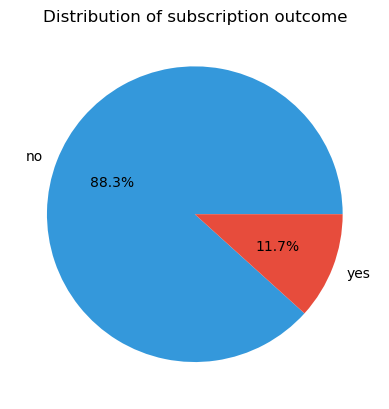


Exact counts:
y
no     39922
yes     5289
Name: count, dtype: int64


In [6]:
## Understanding distribution of target
col_y = "y"

## Pie chart showing the class ratio at a glance
df[col_y].value_counts().plot(kind="pie", autopct="%1.1f%%", colors=["#3498db", "#e74c3c"])
plt.title("Distribution of subscription outcome")
plt.ylabel("")
plt.show()

## Print the actual counts for reference
print("\nExact counts:")
print(df[col_y].value_counts())


**Business interpretation:**
The target is **imbalanced** — about **88% no / 12% yes**. This reflects the business pain (nine out of ten calls miss) and has three important implications for our modelling approach:

1. **Accuracy will be a misleading metric.** A trivial model that always predicts "no" would score 88% accuracy but catch zero subscribers, which is exactly what the bank does NOT want.
2. **We must use metrics that focus on the minority class** — F1-score, recall, and precision on the "yes" class, plus a confusion matrix.
3. **We should use `class_weight='balanced'`** in our classifiers so the model penalises mistakes on the minority "yes" class more heavily than mistakes on the majority "no" class.


### 2.3.1.2 Understanding distribution of features

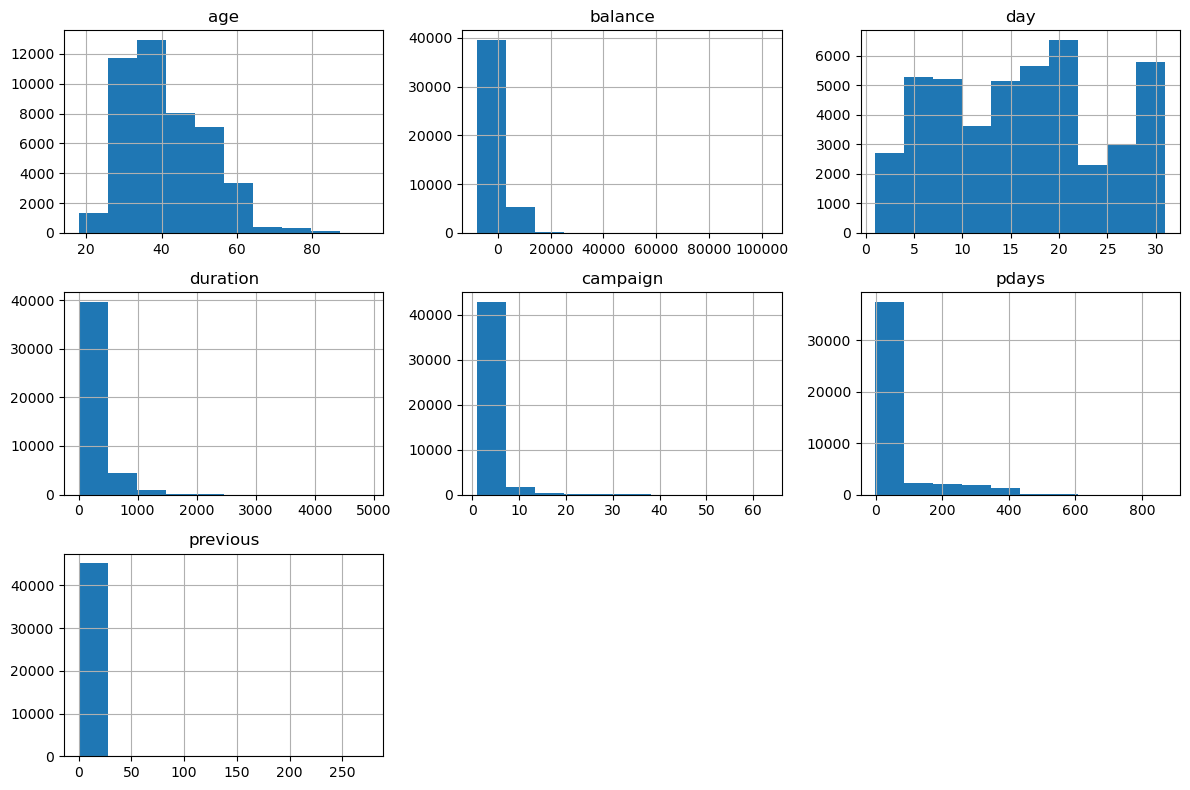

In [7]:
## Distribution of all numerical features using histograms
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


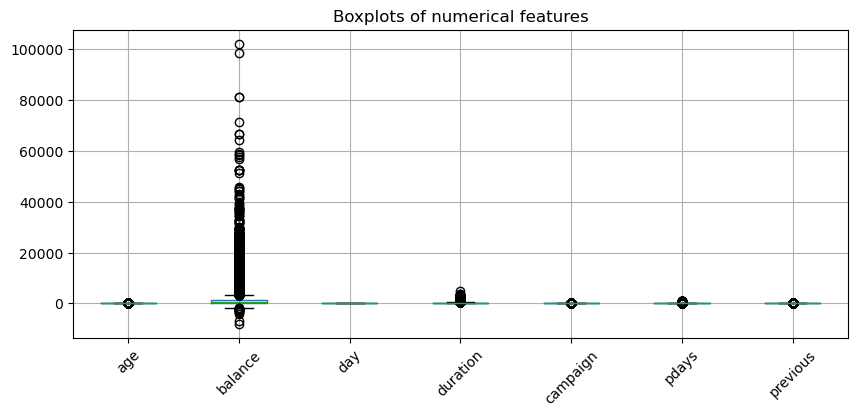

In [8]:
## Boxplots to check spread and outliers of numerical features
df.boxplot(rot=45, figsize=(10, 4))
plt.title("Boxplots of numerical features")
plt.show()


**Observations on numerical distributions:**
- `age` — centred around 30–50 with a long tail to older customers.
- `balance` — strongly right-skewed with negative values (overdrafts) and large positive outliers.
- `duration` — right-skewed. **Flagged for removal (see 3.1) — data leakage.**
- `campaign` — most customers were contacted 1–3 times, a few many more times.
- `pdays` — dominated by -1 (never contacted before).
- `previous` — most customers had zero previous contacts.

**Implication for modelling:** several features are skewed. Random Forest is robust to skew, so we don't need transformation. Logistic Regression can also handle raw skew if we don't scale — we'll rely on Random Forest as our primary model.


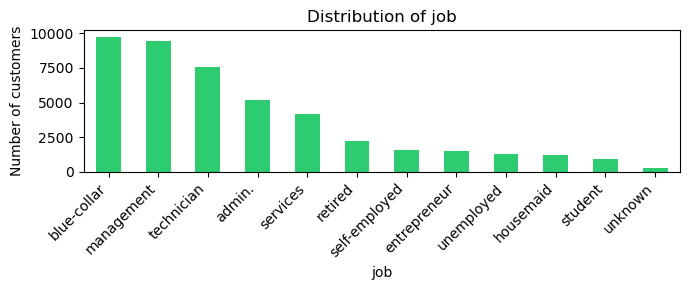

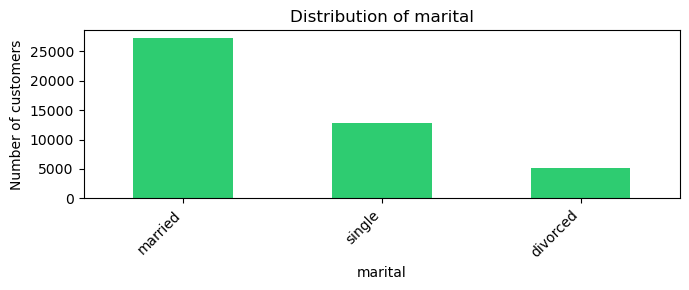

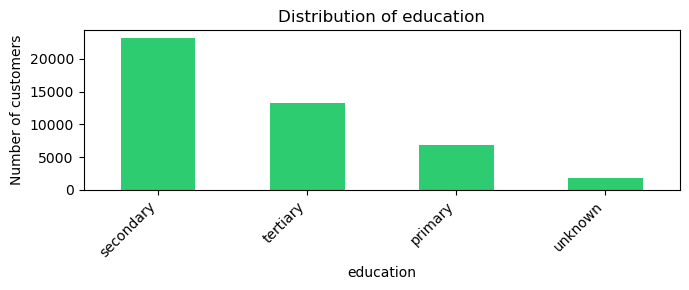

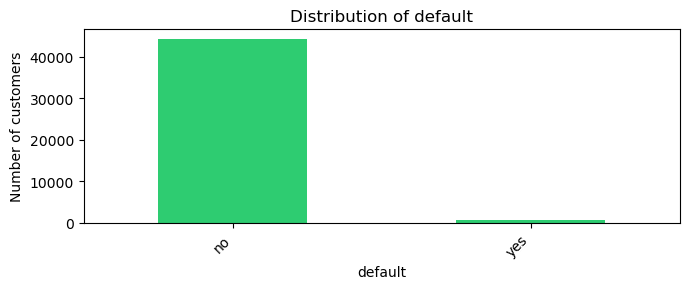

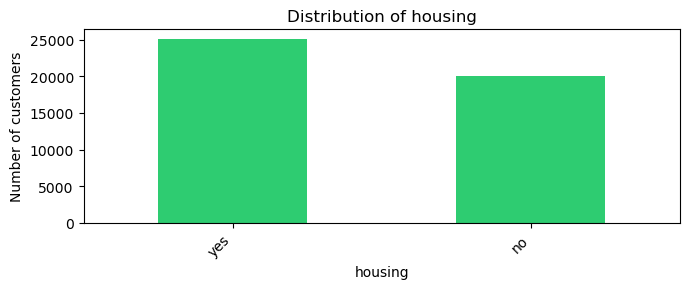

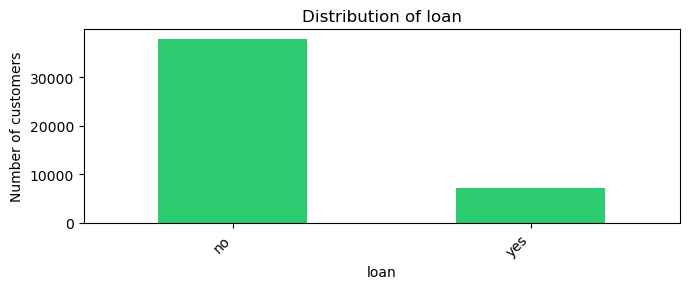

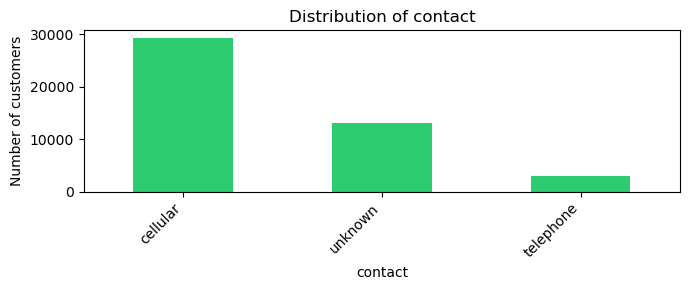

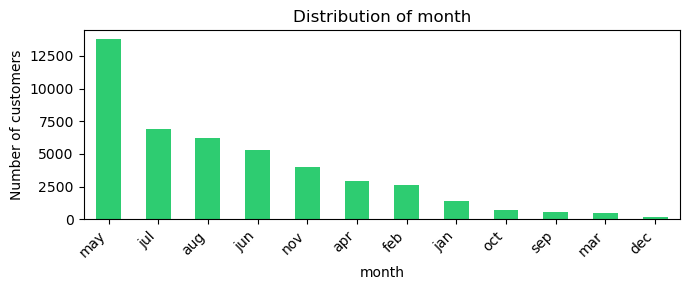

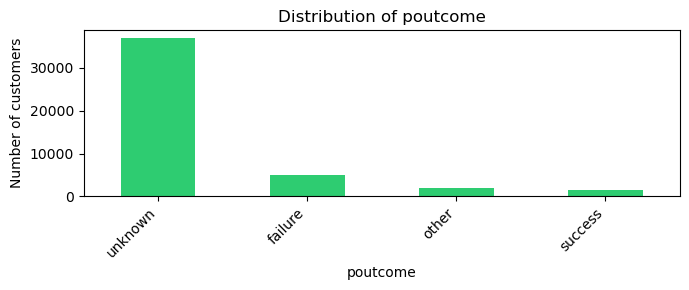

In [9]:
## Distribution of each categorical feature using bar charts
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols.remove(col_y)  ## Exclude target from feature list

for col in cat_cols:
    df[col].value_counts().plot(kind="bar", figsize=(7, 3), color="#2ecc71")
    plt.title(f"Distribution of {col}")
    plt.ylabel("Number of customers")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


**Observations on categorical distributions:**
- `job` — dominated by blue-collar, management, technician.
- `marital` — mostly married.
- `education` — mostly secondary and tertiary; some "unknown".
- `default` / `housing` / `loan` — binary yes/no financial flags. Very few customers with credit default.
- `contact` — many "unknown" (data-quality issue we can flag).
- `month` — campaigns are clustered in May–August.
- `poutcome` — dominated by "unknown" (~82%) — most customers were not in a previous campaign.

**Implication for modelling:** all categories have enough samples to be usable. `poutcome = success` is small in count but (as we'll see next) very predictive.


### 2.3.2 Understanding relationship between variables

We now look at how each feature relates to the target. This is the most business-relevant part of EDA — it tells us **who is more likely to subscribe**.


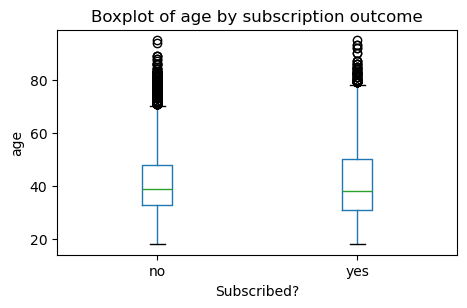

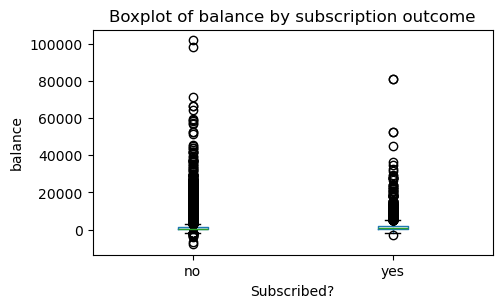

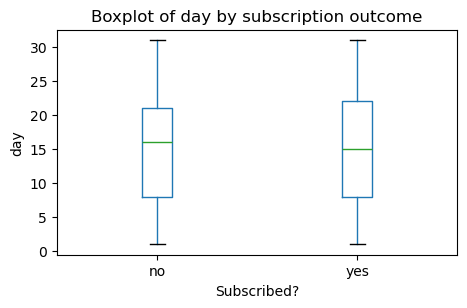

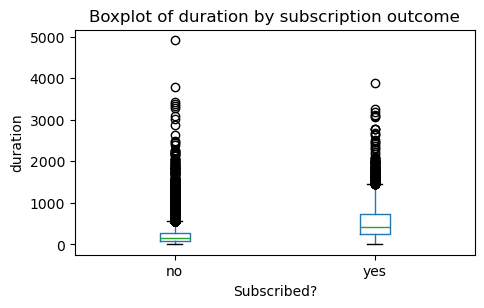

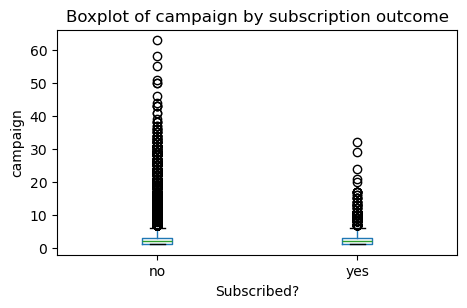

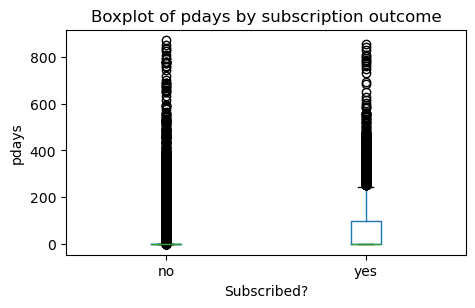

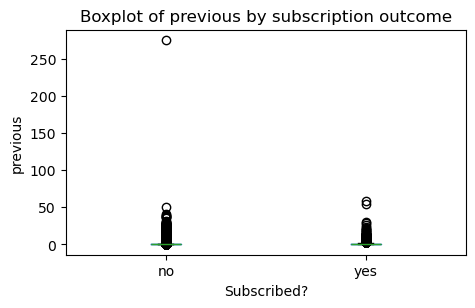

In [10]:
## Boxplot of each numerical feature grouped by the target
## Reveals whether subscribers ("yes") systematically differ from non-subscribers ("no")
for col in df.columns:
    if df[col].dtype == int or df[col].dtype == float:
        df.boxplot(column=col, by=col_y, grid=False, rot=0, figsize=(5, 3))
        plt.title(f"Boxplot of {col} by subscription outcome")
        plt.suptitle("")
        plt.xlabel("Subscribed?")
        plt.ylabel(col)
        plt.show()


**Observations from boxplots by target:**
- `duration` — subscribers had **much longer calls**. This confirms data leakage: it's predictive only because the conversation happened, so we drop it.
- `balance` — subscribers have slightly higher balances on average (they have spare cash to deposit).
- `previous` — subscribers had more previous campaign contacts (past engagement = future engagement).
- `campaign` — non-subscribers were contacted more times this campaign — diminishing returns.
- `pdays` — dominated by -1, so not informative in this form; we'll engineer around it.


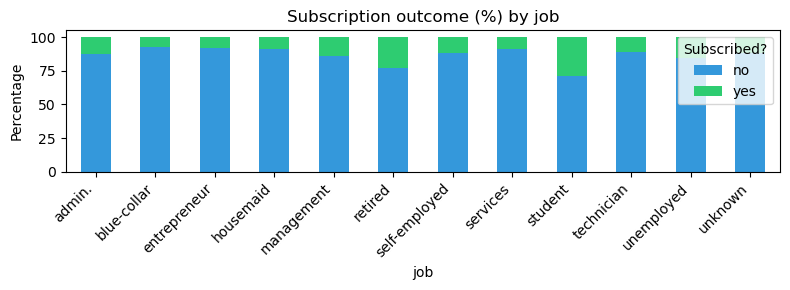

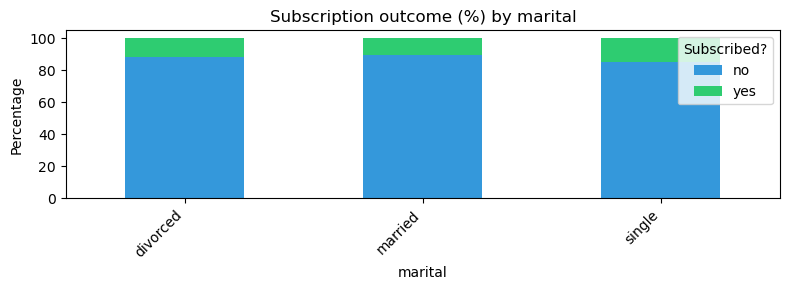

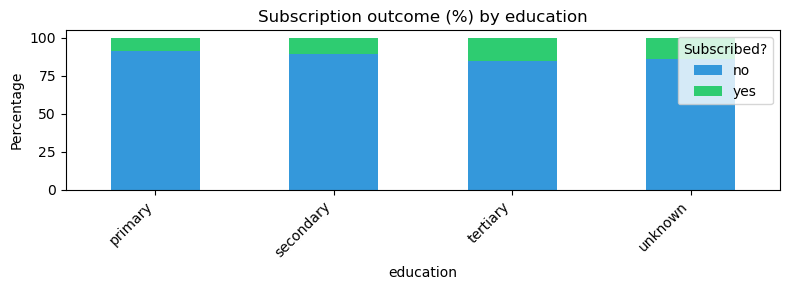

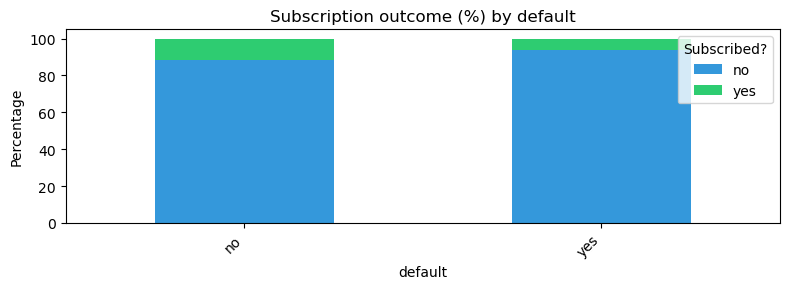

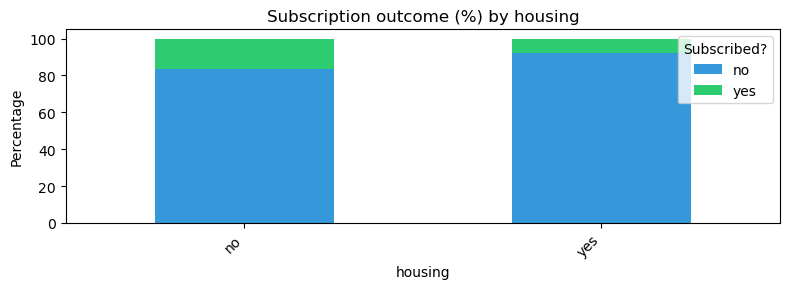

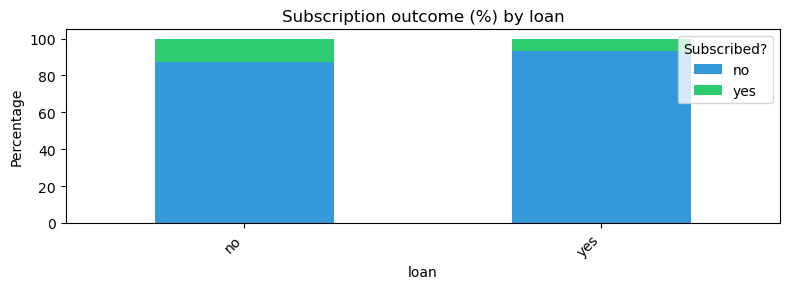

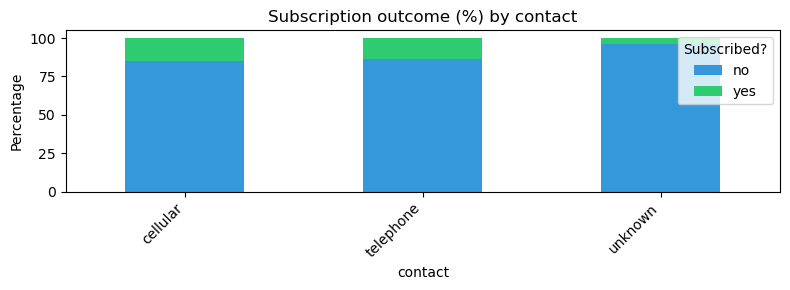

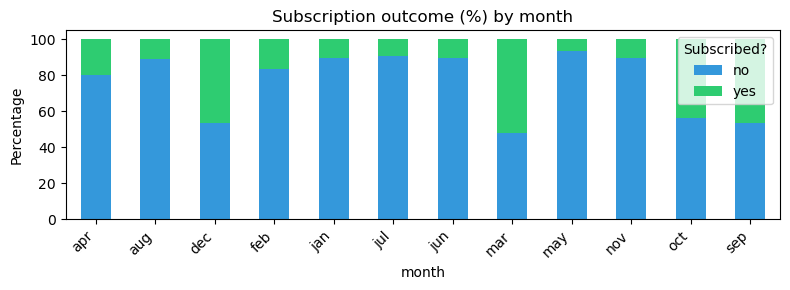

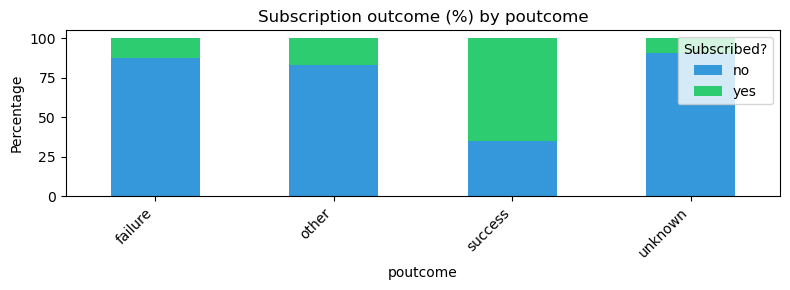

In [11]:
## Stacked bar chart of subscription outcome by each categorical feature
## Uses pd.crosstab with normalize='index' to show the SUBSCRIPTION RATE per category
## (raw counts hide the rate — we want to know who is likely to say yes, not just who is common)
for col in cat_cols:
    ct = pd.crosstab(df[col], df[col_y], normalize="index") * 100
    ct.plot(kind="bar", stacked=True, figsize=(8, 3), color=["#3498db", "#2ecc71"])
    plt.title(f"Subscription outcome (%) by {col}")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Subscribed?", loc="upper right")
    plt.tight_layout()
    plt.show()


**Key business insights (this is where the value is):**
- **`poutcome = success`** shows a dramatic jump in subscription rate — customers who subscribed in a previous campaign are far more likely to subscribe again. **This will likely be our strongest predictor.**
- **`job = student` / `retired`** — subscribe at above-average rates. Students save for the future; retirees seek safe interest income.
- **`contact = cellular`** — outperforms landline and "unknown". Mobile-reached customers are more engaged.
- **`month`** — March, September, October, December show high rates (low-volume warm-lead months).
- **`housing = no`** and **`loan = no`** — customers without existing debt subscribe more (they have spare cash).
- **`education = tertiary`** — educated customers subscribe more.

**Implications for feature engineering:**
1. Extract `previous_success` as a clear binary flag from `poutcome`.
2. Engineer `previously_contacted` from `pdays` (flag whether they were contacted before).
3. Bin `age` into bands to capture non-linear patterns (young + old subscribe more than middle-aged).


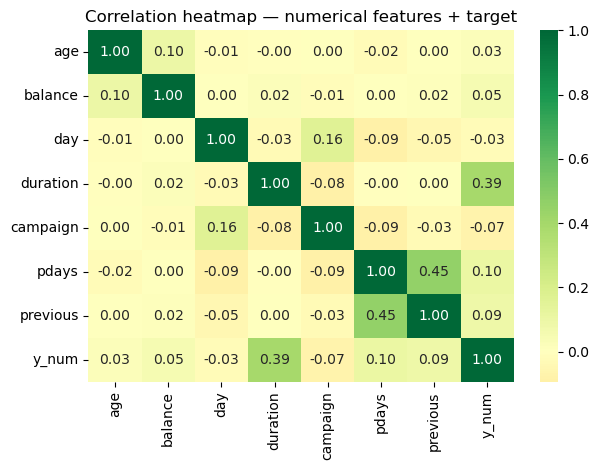

In [12]:
## Correlation heatmap for numerical features
## Also encode target as 0/1 so we can see its correlation with numerical features
df_corr = df.copy()
df_corr["y_num"] = (df_corr[col_y] == "yes").astype(int)

## Select only numeric columns
col_numeric = df_corr.select_dtypes(include=["float64", "int64"]).columns
df_corr_matrix = df_corr[col_numeric].corr()

## Plot heatmap
sns.heatmap(df_corr_matrix, cmap="RdYlGn", annot=True, fmt=".2f", center=0)
plt.title("Correlation heatmap — numerical features + target")
plt.tight_layout()
plt.show()


**Observations from correlation heatmap:**
- No pair of features shows dangerously high correlation (all |r| < 0.7), so **multicollinearity is not a concern**.
- Individual numerical correlations with the target `y_num` are all weak, meaning the signal is spread across many features (including categoricals). This **favours ensemble models like Random Forest** that can combine many weak signals.
- `pdays` and `previous` are moderately correlated (both track prior-contact history). We'll be careful when engineering features from these to avoid double-counting.


# 3. Data Preparation

## 3.1 Data Cleaning

**Cleaning decisions (with rationale):**

1. **Drop `duration`** — data leakage. The UCI documentation explicitly warns:
   > *"This attribute highly affects the output target... yet the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model."*
   
   Our tool must score customers *before* the call, so we drop this column.

2. **Engineer `previously_contacted`** from `pdays`. The -1 sentinel value is not a real number of days — a linear model would treat it as a very negative number of days ago, which is wrong. A binary flag makes it honest.

3. **Engineer `previous_success`** from `poutcome`. Isolates the strongest single signal in the data.

4. **Engineer `age_band`** from `age`. Captures the non-linear U-shape we saw in the EDA (young + old subscribe more).

5. **Encode target** — convert `y` from "yes"/"no" to 1/0 for modelling.


In [13]:
## Clean data

## Make a working copy so we can rerun this cell safely
df_clean = df.copy()

## 1. Drop 'duration' — data leakage (see rationale above)
df_clean = df_clean.drop(columns=["duration"])
print(f"After dropping 'duration': {df_clean.shape}")

## 2. Engineer 'previously_contacted' — clean binary flag from pdays sentinel
df_clean["previously_contacted"] = (df_clean["pdays"] != -1).astype(int)

## 3. Engineer 'previous_success' — clean binary flag from poutcome
df_clean["previous_success"] = (df_clean["poutcome"] == "success").astype(int)

## 4. Engineer 'age_band' — bin age into 5 groups to capture the non-linear U-shape
df_clean["age_band"] = pd.cut(df_clean["age"],
                              bins=[0, 30, 40, 50, 60, 100],
                              labels=["<=30", "31-40", "41-50", "51-60", "60+"])

## 5. Encode target as 0/1 (1 = yes, 0 = no)
df_clean[col_y] = (df_clean[col_y] == "yes").astype(int)

## Preview the cleaned dataframe
print("\nEngineered features preview:")
df_clean[["age", "age_band", "pdays", "previously_contacted", "poutcome", "previous_success", col_y]].head(10)


After dropping 'duration': (45211, 16)

Engineered features preview:


,age,age_band,pdays,previously_contacted,poutcome,previous_success,y
0,58,51-60,-1,0,unknown,0,0
1,44,41-50,-1,0,unknown,0,0
2,33,31-40,-1,0,unknown,0,0
3,47,41-50,-1,0,unknown,0,0
4,33,31-40,-1,0,unknown,0,0
5,35,31-40,-1,0,unknown,0,0
6,28,<=30,-1,0,unknown,0,0
7,42,41-50,-1,0,unknown,0,0
8,58,51-60,-1,0,unknown,0,0
9,43,41-50,-1,0,unknown,0,0


## 3.2 Train-Test Split

In [14]:
## Split data into features (X) and target (y)
from sklearn.model_selection import train_test_split

## Separate features and target
y = df_clean[col_y]
X = df_clean.drop(columns=[col_y])

## Convert categorical variables into numerical format (one-hot encoding)
## drop_first=True avoids the dummy variable trap for Logistic Regression
X = pd.get_dummies(X, drop_first=True)

print(f"Feature matrix shape after one-hot encoding: {X.shape}")
print(f"Number of features after encoding: {X.shape[1]}")

## Split dataset into training and testing sets (70/30)
## Use stratify=y because the target is imbalanced — preserves the 88/12 ratio in both sets
test_size = 0.3
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=test_size,
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

## Verify stratification worked — class ratio should be same in train and test
print(f"\nClass ratio in train set: {y_train.mean():.4f}")
print(f"Class ratio in test set:  {y_test.mean():.4f}")


Feature matrix shape after one-hot encoding: (45211, 47)
Number of features after encoding: 47

X_train: (31647, 47), y_train: (31647,)
X_test:  (13564, 47), y_test:  (13564,)

Class ratio in train set: 0.1170
Class ratio in test set:  0.1170


**Why `stratify=y`?** Because our target is imbalanced (88% no / 12% yes), a random split could accidentally give us a test set with a very different class ratio, making our evaluation unreliable. `stratify=y` guarantees the 88/12 ratio is preserved in both train and test sets.
